# 3D Straight-edge Extraction Pipeline

This notebook implements a five-stage pipeline for extracting three-dimensional straight edges from point clouds, following the method described in the paper excerpt provided:

1. Build a 3D triangular surface (mesh) using the Ball Pivoting Algorithm (BPA).
2. Compute triangle normals and assign per-mesh-edge angle (angle between normals of adjacent triangles).
3. Use graph-based filtering to keep edges likely to belong to straight 3D edges; segment remaining edges into groups.
4. Fit a least-squares 3D line to each edge group (PCA/SVD) to obtain a representative line segment.
5. Extend the fitted segments using a RANSAC-like extension procedure to maximize the straight-edge extent.

This notebook is a runnable skeleton: adapt parameters and thresholds to your data. It uses Open3D, NumPy, NetworkX and SciPy.

In [6]:
# Environment & Imports

# Core libraries
import os, time
import numpy as np

# Optional: Open3D for point cloud / mesh processing
try:
    import open3d as o3d
    try:
        from open3d.web_visualizer import draw as draw_web
    except Exception:
        draw_web = None
except Exception as e:
    o3d = None
    draw_web = None
    print('Open3D not available. Install with: pip install open3d')

# Graph & spatial helpers
import networkx as nx
from scipy.spatial import cKDTree

# Linear algebra / fitting
from sklearn.decomposition import PCA

# Visualization
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (8,6)

# Reproducible defaults
np.random.seed(0)

# Helper: small function to check availability
def require_open3d():
    if o3d is None:
        raise RuntimeError('Open3D is required for this notebook. Install with: pip install open3d')


In [7]:
# Parameters / configuration
# Point cloud path (set to your file). If left as None the notebook will try to auto-resolve
# a recently exported point-cloud from the 2D analysis notebook (searches JSON shortcut or depth_boundary_*.ply).
point_cloud_path = None  # e.g. r'C:\\path\\to\\scan.ply' or None to auto-resolve
output_dir = r'./3d_edge_output'
os.makedirs(output_dir, exist_ok=True)

# Preprocessing
voxel_size = None  # if None, will compute from average spacing
downsample_voxel = 0.01  # meters (example)
remove_outliers = True
nb_neighbors = 20
std_ratio = 2.0

# BPA / mesh construction
bpa_radius_factor = 1.5  # multiplies estimated spacing to obtain radius r
bpa_radii = None  # if None will be computed from spacing

# Normal & edge thresholds
normal_radius = None  # if None derived from spacing
angle_thresh_deg = 20.0  # threshold (deg) to consider an edge 'sharp'
min_edge_length = 0.01  # meters

# Graph / segmentation
merge_dist = 1.0  # merge nearby components (m)
dir_tol_deg = 15.0
min_segment_size = 5  # minimum number of edges/points in a segment

# Least squares fitting
lsq_rmse_thresh = 0.02  # discard fits with RMSE > threshold (m)

# RANSAC extension
ransac_iters = 200
ransac_distance = 0.02
min_inliers = 10
extension_search_radius = 0.05

# Visualization options
visualize_intermediate = True
vis_backend = 'desktop'  # 'web' (open3d.web_visualizer) or 'desktop' (draw_geometries)
desktop_camera = None
# Example (uncomment to use):
# desktop_camera = dict(
#     zoom=0.35,
#     front=[0.4, -0.2, -0.88],
#     lookat=[0.0, 0.0, 0.0],
#     up=[-0.07, -0.98, 0.20],
# )

# Save results
save_results = True

print('Parameters: voxel_size=', voxel_size, 'angle_thresh_deg=', angle_thresh_deg, 'vis_backend=', vis_backend)


Parameters: voxel_size= None angle_thresh_deg= 20.0 vis_backend= desktop


In [8]:
# Auto-resolve a point-cloud exported by the 2D depth analysis notebook (robust / recursive)
# This helper prefers a JSON shortcut written by the 2D notebook, then falls back to the most recent depth_boundary_*.ply

import glob, json, os

def resolve_point_cloud_path(existing=None, search_dirs=None, workspace_root=None):
    """Try to resolve a point-cloud path when not explicitly provided.

    Priority:
      1) existing (if given and exists)
      2) timestamped JSON shortcut files named last_export_pointcloud_*.json (searched recursively in common locations)
      3) depth_boundary_*.ply files (most recent, searched recursively)

    Returns: absolute path or None
    """
    # 1) explicit path
    if existing:
        if os.path.isfile(existing):
            return os.path.abspath(existing)

    # Prepare search roots
    if workspace_root is None:
        # Notebook cwd is usually the repository root or notebook folder; use it as base
        workspace_root = os.getcwd()

    default_dirs = [
        os.getcwd(),
        os.path.abspath('.'),
        os.path.abspath('..'),
        os.path.join(workspace_root, 'output_3d_blocks'),
        os.path.join(workspace_root, 'scripts', 'unity_yolo', 'output_3d_blocks'),
        os.path.join(workspace_root, 'runs'),
        os.path.join(workspace_root, 'raw'),
        os.path.join(workspace_root, 'scripts', 'post_analysis'),
    ]

    if search_dirs:
        # user-provided dirs take precedence
        scan_dirs = list(search_dirs) + default_dirs
    else:
        scan_dirs = default_dirs

    # 2) Look for JSON shortcuts first (recursive search)
    json_candidates = []
    for d in scan_dirs:
        if not os.path.isdir(d):
            continue
        json_candidates += glob.glob(os.path.join(d, '**', 'last_export_pointcloud_*.json'), recursive=True)
        json_candidates += glob.glob(os.path.join(d, '**', 'last_export_pointcloud.json'), recursive=True)

    if json_candidates:
        latest = max(json_candidates, key=os.path.getmtime)
        try:
            with open(latest, 'r') as f:
                j = json.load(f)
            pc = j.get('point_cloud')
            if pc:
                # make relative paths relative to the json file
                if not os.path.isabs(pc):
                    pc = os.path.join(os.path.dirname(latest), pc)
                if os.path.isfile(pc):
                    print('Resolved point_cloud_path from JSON shortcut:', latest)
                    return os.path.abspath(pc)
        except Exception:
            pass

    # 3) Fallback to searching for depth_boundary_*.ply files recursively
    ply_candidates = []
    for d in scan_dirs:
        if not os.path.isdir(d):
            continue
        ply_candidates += glob.glob(os.path.join(d, '**', 'depth_boundary_*.ply'), recursive=True)

    if ply_candidates:
        latest = max(ply_candidates, key=os.path.getmtime)
        print('Resolved point_cloud_path to latest PLY:', latest)
        return os.path.abspath(latest)

    # Nothing found
    return None

# Common search places (add or customize if your exports live elsewhere)
search_dirs = [
    os.getcwd(),
    os.path.join(os.getcwd(), 'raw'),
    os.path.join(os.getcwd(), 'output_3d_blocks'),
    os.path.join(os.getcwd(), 'scripts', 'unity_yolo', 'output_3d_blocks'),
]

# If the notebook user didn't set `point_cloud_path` earlier, set it now by auto-resolve
try:
    point_cloud_path  # noqa: F821
except NameError:
    point_cloud_path = None

point_cloud_path = resolve_point_cloud_path(point_cloud_path, search_dirs, workspace_root=None)
print('point_cloud_path =', point_cloud_path)


Resolved point_cloud_path from JSON shortcut: c:\Users\1213123\Documents\Scripts\FoundationStereo\scripts\unity_yolo\output_3d_blocks\raw\last_export_pointcloud.json
point_cloud_path = c:\Users\1213123\Documents\Scripts\FoundationStereo\scripts\unity_yolo\output_3d_blocks\raw\depth_boundary.ply


In [9]:
# Stage 1: Load point cloud and preprocessing
require_open3d()

if not point_cloud_path:
    print('Set `point_cloud_path` in the parameters cell and re-run this cell.')
else:
    pcd = o3d.io.read_point_cloud(point_cloud_path)
    print('Loaded point cloud: points =', np.asarray(pcd.points).shape[0])

    # Estimate average spacing via kNN
    pts = np.asarray(pcd.points)
    if pts.shape[0] < 10:
        raise RuntimeError('Point cloud too small')

    kdt = cKDTree(pts)
    dists, _ = kdt.query(pts, k=6)
    spacing = float(np.mean(dists[:, -1]))
    print('Estimated average spacing (approx):', spacing)

    # Decide voxel size / radii
    if voxel_size is None:
        voxel_size = max( spacing * 0.5, 1e-4 )
    if bpa_radii is None:
        r = bpa_radius_factor * spacing
        bpa_radii = [r, 2*r, 4*r]
    if normal_radius is None:
        normal_radius = spacing * 2.0

    print('voxel_size, radii, normal_radius =', voxel_size, bpa_radii, normal_radius)

    # Downsample if requested
    if downsample_voxel is not None and downsample_voxel > 0:
        pcd_ds = pcd.voxel_down_sample(downsample_voxel)
        print('Downsampled: from', len(pcd.points), 'to', len(pcd_ds.points))
        pcd = pcd_ds

    # Remove outliers
    if remove_outliers:
        pcd, ind = pcd.remove_statistical_outlier(nb_neighbors=nb_neighbors, std_ratio=std_ratio)
        print('After outlier removal: points =', len(pcd.points))

    # Normals
    if not pcd.has_normals():
        pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamRadius(normal_radius))
        pcd.orient_normals_consistent_tangent_plane(100)
    print('Normals ready')

    # Build mesh using Ball Pivoting Algorithm
    mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(
        pcd, o3d.utility.DoubleVector(bpa_radii)
    )
    mesh.remove_unreferenced_vertices()
    mesh.compute_vertex_normals()
    mesh.compute_triangle_normals()
    print('Mesh: triangles=', np.asarray(mesh.triangles).shape[0], 'vertices=', np.asarray(mesh.vertices).shape[0])

    # Visualization (simple + minimal guards)
    if visualize_intermediate and mesh is not None:
        # Prepare visuals (clone if available)
        mesh_vis = mesh.clone() if hasattr(mesh, 'clone') else mesh
        mesh_vis.compute_vertex_normals()
        mesh_vis.paint_uniform_color([0.85, 0.85, 0.85])
        pcd_vis = pcd

        # Compute sharp edges (angle between adjacent triangle normals >= angle_thresh_deg)
        triangles = np.asarray(mesh.triangles)
        tri_normals = np.asarray(mesh.triangle_normals)
        vertices = np.asarray(mesh.vertices)

        from collections import defaultdict
        edge_to_tris = defaultdict(list)
        for t_idx, tri in enumerate(triangles):
            a,b,c = int(tri[0]), int(tri[1]), int(tri[2])
            for u,v in ((a,b),(b,c),(c,a)):
                key = (u,v) if u < v else (v,u)
                edge_to_tris[key].append(t_idx)

        pts_ls = []
        lines_idx = []
        for (a, b), tris in edge_to_tris.items():
            if len(tris) == 2:
                n1 = tri_normals[tris[0]]
                n2 = tri_normals[tris[1]]
                cosv = np.clip(np.dot(n1, n2), -1.0, 1.0)
                ang = np.degrees(np.arccos(cosv))
                if ang >= angle_thresh_deg:
                    pts_ls.append(vertices[a].tolist())
                    pts_ls.append(vertices[b].tolist())
                    lines_idx.append([len(pts_ls)-2, len(pts_ls)-1])

        ls = None
        if len(lines_idx) > 0:
            ls = o3d.geometry.LineSet()
            ls.points = o3d.utility.Vector3dVector(np.array(pts_ls))
            ls.lines = o3d.utility.Vector2iVector(np.array(lines_idx))
            ls.colors = o3d.utility.Vector3dVector(np.array([[1.0, 0.0, 0.0] for _ in lines_idx]))

        # Show with chosen backend
        if vis_backend == 'web' and draw_web is not None:
            geos = [
                {"name": "point_cloud", "geometry": pcd_vis},
                {"name": "mesh", "geometry": mesh_vis},
            ]
            if ls is not None:
                geos.append({"name": "sharp_edges", "geometry": ls})
            draw_web(geos, title="3D Edge Pipeline - Mesh Preview", width=1024, height=768)
        else:
            geolist = [pcd_vis, mesh_vis] + ([ls] if ls is not None else [])
            if desktop_camera and isinstance(desktop_camera, dict):
                o3d.visualization.draw_geometries(
                    geolist,
                    zoom=desktop_camera.get('zoom', 0.35),
                    front=desktop_camera.get('front', [0.4, -0.2, -0.88]),
                    lookat=desktop_camera.get('lookat', [0.0, 0.0, 0.0]),
                    up=desktop_camera.get('up', [-0.07, -0.98, 0.20])
                )
            else:
                o3d.visualization.draw_geometries(geolist)


Loaded point cloud: points = 2068
Estimated average spacing (approx): 2.155262335818984
voxel_size, radii, normal_radius = 1.077631167909492 [3.2328935037284765, 6.465787007456953, 12.931574014913906] 4.310524671637968
Downsampled: from 2068 to 2068
After outlier removal: points = 2055
Normals ready
Mesh: triangles= 3833 vertices= 1965


## Visualization tips (from Open3D tutorial)

- Desktop viewer controls: Left-drag = rotate, Ctrl+Left-drag = translate, Mouse wheel = zoom, Shift+Left-drag = roll. Press H for full help.
- Save/restore view: In the desktop viewer, use Ctrl+C to copy current view to clipboard and Ctrl+V to restore it later.
- Web viewer: The web visualizer shows a toolbar for orbit, pan, and zoom. Use the built-in controls to adjust the camera; refresh to reset.
- You can switch backends via the parameter `vis_backend = 'web' | 'desktop'`. For the desktop backend, you can provide `desktop_camera` with zoom/front/lookat/up to reproduce a view.


Total mesh edges: 5807


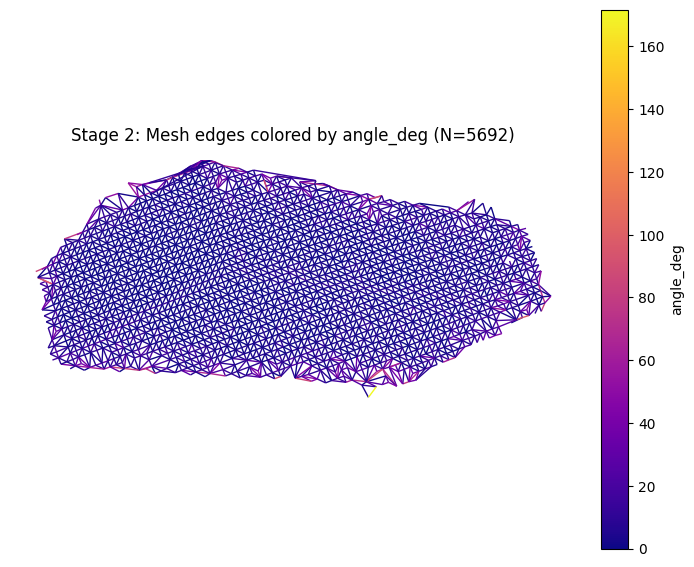

In [10]:
# Stage 2: Triangle normals & per-edge angle assignment
require_open3d()
if mesh is None:
    raise RuntimeError('Mesh not available from Stage 1')

# Build edge -> triangle adjacency
triangles = np.asarray(mesh.triangles)
vertices = np.asarray(mesh.vertices)
tri_normals = np.asarray(mesh.triangle_normals)

# Helper: produce sorted edge key for undirected edge
from collections import defaultdict
edge_to_tris = defaultdict(list)
for t_idx, tri in enumerate(triangles):
    edges = [(tri[0], tri[1]), (tri[1], tri[2]), (tri[2], tri[0])]
    for a,b in edges:
        key = tuple(sorted((int(a), int(b))))
        edge_to_tris[key].append(int(t_idx))

# compute per-edge attributes
edges_list = []
for (a,b), tris in edge_to_tris.items():
    p0 = vertices[a]
    p1 = vertices[b]
    midpoint = 0.5 * (p0 + p1)
    length = np.linalg.norm(p1 - p0)
    angle_rad = None
    angle_deg = None
    if len(tris) == 2:
        n1 = tri_normals[tris[0]]
        n2 = tri_normals[tris[1]]
        cosv = np.clip(np.dot(n1, n2), -1.0, 1.0)
        angle_rad = np.arccos(cosv)
        angle_deg = np.degrees(angle_rad)
    # record
    edges_list.append({
        'verts': (int(a), int(b)),
        'tris': list(tris),
        'midpoint': midpoint,
        'length': float(length),
        'angle_rad': angle_rad,
        'angle_deg': angle_deg
    })

print('Total mesh edges:', len(edges_list))

# Quick 2D plot of mesh edges colored by angle_deg (after Stage 2)
if visualize_intermediate:
    # Keep edges with a defined angle (two adjacent triangles) and length threshold
    edges_plot = [e for e in edges_list if (e['angle_deg'] is not None and e['length'] >= min_edge_length)]
    if len(edges_plot) == 0:
        print('Stage 2: no edges to plot (after filtering by length/angle presence).')
    else:
        # Build endpoints and angles
        P0 = np.array([vertices[e['verts'][0]] for e in edges_plot])  # Nx3
        P1 = np.array([vertices[e['verts'][1]] for e in edges_plot])  # Nx3
        angles = np.array([e['angle_deg'] for e in edges_plot])

        # PCA projection to 2D for a stable layout
        X = np.vstack([P0, P1])
        X_mean = X.mean(axis=0)
        Xc = X - X_mean
        if Xc.shape[0] >= 2:
            U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
            basis2 = Vt[:2].T  # 3x2
            proj0 = (P0 - X_mean).dot(basis2)
            proj1 = (P1 - X_mean).dot(basis2)
        else:
            # Fallback: take first two coordinates
            proj0 = P0[:, :2]
            proj1 = P1[:, :2]

        # Plot with a LineCollection colored by angle
        from matplotlib.collections import LineCollection
        import matplotlib.cm as cm
        from matplotlib.colors import Normalize

        segments = [[(proj0[i,0], proj0[i,1]), (proj1[i,0], proj1[i,1])] for i in range(len(edges_plot))]
        vmin = float(np.nanmin(angles)) if angles.size > 0 else 0.0
        vmax = float(np.nanmax(angles)) if angles.size > 0 else 1.0
        norm = Normalize(vmin=vmin, vmax=vmax)

        lc = LineCollection(segments, cmap=cm.plasma, norm=norm, linewidths=1.0)
        lc.set_array(angles)

        fig, ax = plt.subplots(figsize=(8,7))
        ax.add_collection(lc)
        ax.autoscale()
        ax.set_aspect('equal', adjustable='box')
        ax.set_title(f'Stage 2: Mesh edges colored by angle_deg (N={len(edges_plot)})')
        cbar = fig.colorbar(lc, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('angle_deg')
        ax.axis('off')
        plt.show()

Segments found: 16


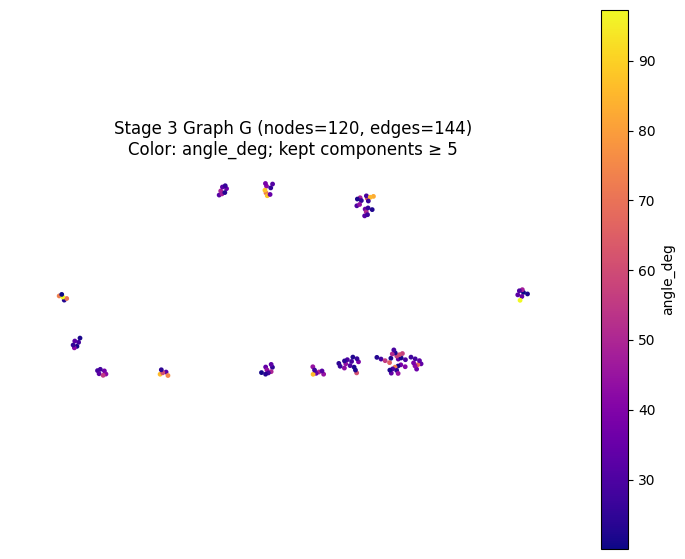

In [11]:
# Stage 3: Graph-based filtering and segmentation of finite edges

# Build node list from edges_list where edge has two adjacent triangles and is long enough
nodes = []
for i, e in enumerate(edges_list):
    if e['angle_deg'] is None:
        continue
    if e['length'] < min_edge_length:
        continue
    nodes.append((i, e))

# Build KD-tree of midpoints for spatial adjacency
midpoints = np.array([e['midpoint'] for _, e in nodes])
if len(midpoints) == 0:
    raise RuntimeError('No candidate edges found; check thresholds')
mid_kdt = cKDTree(midpoints)

G = nx.Graph()
for idx, e in nodes:
    G.add_node(idx, angle_deg=e['angle_deg'], length=e['length'], midpoint=e['midpoint'])

# Connect nodes if their midpoints are within merge_dist and share a vertex (heuristic)
pairs = mid_kdt.query_pairs(r=merge_dist)
for a,b in pairs:
    idx_a = nodes[a][0]
    idx_b = nodes[b][0]
    # compute direction compatibility (optional)
    G.add_edge(idx_a, idx_b)

# Prune nodes by angle threshold
to_remove = [n for n, data in G.nodes(data=True) if data.get('angle_deg',0.0) < angle_thresh_deg]
G.remove_nodes_from(to_remove)

# Connected components -> segments
components = [list(c) for c in nx.connected_components(G) if len(c) >= min_segment_size]
print('Segments found:', len(components))

# Plot the graph G (after pruning) focusing on kept components
if visualize_intermediate:
    kept_nodes = set().union(*components) if len(components) > 0 else set()
    if len(kept_nodes) == 0:
        print('Graph G has no components meeting min_segment_size; skipping graph plot.')
    else:
        H = G.subgraph(kept_nodes).copy()
        # Map node index -> midpoint
        idx_to_mid = {nodes[i][0]: midpoints[i] for i in range(len(nodes))}
        nodes_in_H = list(H.nodes())
        X = np.array([idx_to_mid[n] for n in nodes_in_H])  # Nx3 midpoints
        # Layout: PCA to 2D for a stable geometric view; spring layout fallback if needed
        pos2d = {}
        if X.shape[0] >= 2:
            Xc = X - X.mean(axis=0)
            U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
            basis2 = Vt[:2].T  # 3x2
            proj = Xc.dot(basis2)  # Nx2
            for i, n in enumerate(nodes_in_H):
                pos2d[n] = (float(proj[i,0]), float(proj[i,1]))
        else:
            pos2d = nx.spring_layout(H, seed=0)

        # Node colors by angle_deg
        import matplotlib.cm as cm
        from matplotlib.colors import Normalize
        angles = np.array([H.nodes[n].get('angle_deg', 0.0) for n in H.nodes()])
        vmin = float(np.nanmin(angles)) if angles.size > 0 else 0.0
        vmax = float(np.nanmax(angles)) if angles.size > 0 else 1.0
        norm = Normalize(vmin=vmin, vmax=vmax)
        node_colors = cm.plasma(norm(angles)) if angles.size > 0 else 'steelblue'

        fig, ax = plt.subplots(figsize=(8,7))
        nx.draw_networkx_edges(H, pos2d, width=0.6, alpha=0.35, edge_color='gray', ax=ax)
        nx.draw_networkx_nodes(H, pos2d, node_color=node_colors, node_size=12, linewidths=0.0, ax=ax)
        ax.set_title(f"Stage 3 Graph G (nodes={H.number_of_nodes()}, edges={H.number_of_edges()})\nColor: angle_deg; kept components ≥ {min_segment_size}")
        if angles.size > 0:
            sm = cm.ScalarMappable(cmap=cm.plasma, norm=norm)
            sm.set_array([])
            cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
            cbar.set_label('angle_deg')
        ax.set_aspect('equal', adjustable='box')
        ax.axis('off')
        plt.show()

In [12]:
# Stage 4: Least-squares line fitting for each edge segment

def fit_line_svd(points):
    # points: Nx3
    centroid = points.mean(axis=0)
    X = points - centroid
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    direction = Vt[0]
    # projections onto line
    t = X.dot(direction)
    tmin, tmax = t.min(), t.max()
    p1 = centroid + tmin * direction
    p2 = centroid + tmax * direction
    residuals = np.linalg.norm((X - np.outer(t, direction)), axis=1)
    rmse = float(np.sqrt(np.mean(residuals**2)))
    return dict(centroid=centroid, direction=direction/np.linalg.norm(direction), p1=p1, p2=p2, rmse=rmse)

fitted_segments = []
for comp in components:
    pts = np.array([edges_list[idx]['midpoint'] for idx in comp])
    if pts.shape[0] < 2:
        continue
    fit = fit_line_svd(pts)
    if fit['rmse'] > lsq_rmse_thresh:
        continue
    fitted_segments.append({'indices': comp, 'fit': fit, 'n_points': pts.shape[0]})

print('Fitted segments kept:', len(fitted_segments))


Fitted segments kept: 0


In [13]:
# Stage 5: RANSAC-based extension of line segments

def extend_segment_with_ransac(fit, candidate_pts, dist_thresh=ransac_distance, iters=ransac_iters, min_inliers=min_inliers):
    # fit: dict from fit_line_svd with centroid/direction
    best = {'inliers': [], 'p1': fit['p1'], 'p2': fit['p2']}
    dir_vec = fit['direction'] / np.linalg.norm(fit['direction'])
    # project candidate points
    X = candidate_pts - fit['centroid']
    t = X.dot(dir_vec)
    pts_proj = fit['centroid'] + np.outer(t, dir_vec)
    dists = np.linalg.norm(candidate_pts - pts_proj, axis=1)

    # simple extension heuristic: accept points within distance and expand endpoints
    inlier_mask = dists <= dist_thresh
    if inlier_mask.sum() < min_inliers:
        return best, inlier_mask
    t_in = t[inlier_mask]
    tmin, tmax = t_in.min(), t_in.max()
    new_p1 = fit['centroid'] + tmin * dir_vec
    new_p2 = fit['centroid'] + tmax * dir_vec
    best['inliers'] = np.where(inlier_mask)[0].tolist()
    best['p1'] = new_p1
    best['p2'] = new_p2
    return best, inlier_mask

# Build a global candidate point set from mesh vertices (or edge endpoints)
mesh_pts = vertices
kdt_mesh = cKDTree(mesh_pts)
final_edges = []
for seg in fitted_segments:
    fit = seg['fit']
    # candidate points: points within search radius of current segment (from bbox)
    mid = 0.5 * (fit['p1'] + fit['p2'])
    idxs = kdt_mesh.query_ball_point(mid, r=extension_search_radius)
    candidates = mesh_pts[idxs] if len(idxs) > 0 else np.empty((0,3))
    best, mask = extend_segment_with_ransac(fit, candidates)
    final_edges.append({
        'p1': best['p1'],
        'p2': best['p2'],
        'direction': fit['direction'],
        'inliers': best['inliers'],
        'n_support': len(best['inliers'])
    })

print('Final edges produced:', len(final_edges))


Final edges produced: 0


In [14]:
# Visualization & export helpers

def make_lineset_from_edges(edges, colors=None):
    # edges: list of dict with p1,p2
    pts = []
    lines = []
    line_colors = []
    for i,e in enumerate(edges):
        p1 = np.asarray(e['p1'])
        p2 = np.asarray(e['p2'])
        pts.append(p1)
        pts.append(p2)
        lines.append([2*i, 2*i+1])
        if colors is not None:
            line_colors.append(colors[i])
        else:
            line_colors.append([1.0, 0.0, 0.0])
    if len(pts) == 0:
        return None
    ls = o3d.geometry.LineSet()
    ls.points = o3d.utility.Vector3dVector(np.array(pts))
    ls.lines = o3d.utility.Vector2iVector(np.array(lines))
    ls.colors = o3d.utility.Vector3dVector(np.array(line_colors))
    return ls

# Visualize final edges with point cloud and mesh
if visualize_intermediate and len(final_edges) > 0:
    require_open3d()
    ls = make_lineset_from_edges(final_edges)
    geo = [pcd]
    if mesh is not None:
        mesh_t = mesh.clone() if hasattr(mesh, 'clone') else mesh
        mesh_t.compute_vertex_normals()
        mesh_t.paint_uniform_color([0.7,0.7,0.7])
        geo.append(mesh_t)
    if ls is not None:
        geo.append(ls)
    o3d.visualization.draw_geometries(geo)

# Save final edges
if save_results and len(final_edges) > 0:
    out_npz = os.path.join(output_dir, 'final_edges.npz')
    # convert arrays to saveable structures
    starts = np.array([e['p1'] for e in final_edges])
    ends = np.array([e['p2'] for e in final_edges])
    dirs = np.array([e['direction'] for e in final_edges])
    supports = np.array([e['n_support'] for e in final_edges])
    np.savez_compressed(out_npz, starts=starts, ends=ends, dirs=dirs, supports=supports)
    print('Saved final edges to', out_npz)